<a href="https://colab.research.google.com/github/yyalexlee/EastAsiaClimateExtremes/blob/main/CODES/Extreme_ECMWF_Statistics_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Extreme Comparison on Model data (ECMWF) with Observational data (ERA5)**



*   Updated: July 8 2026
*   Team: ART (AI-based Prediction Research and Technology, APEC Climate Center)
*   Contact: Uran Chung (uchung@apcc21.org)





> This exercise is designed to evaluate the performance of the **ECMWF S2S hindcasts** (versions 2016 and 2024) using two comparisons with the **ERA5 reanalysis**: **(1)** **the frequency of Anomalously High Temperatures** (AHT) during Week 3 and **(2)** **the three-week time series of AHT** at a selected location (e.g., Seoul) for a representative year (e.g., 2023).






*   Model Data: Directory **3.Daily_ECMWFhindcasts**
*   Observation Data: Directory **2.Weekly_ERA5**



> First, compare the **Frequency** of Abnormal High Temperatures (AHT)

**You will need to mount your Google Drive to practice.**

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


* **Cartopy** requires a declaration after **installation**, so it is installed first.

In [2]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 67.4 MB/s eta 0:00:00


*   Declare necessary libraries


In [6]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from dask.diagnostics import ProgressBar


*   Set **Paths** work on



In [7]:
# PATH: ECMWF and ERA5 data
Data_ECMWF = '/content/gdrive/My Drive/Colab Notebooks/APCC/Data/3.Daily_ECMWFhindcasts'
Data_ERA5 = '/content/gdrive/My Drive/Colab Notebooks/APCC/Data/2.Weekly_ERA5'

In [8]:
# PATH: Output
Output_Figures = '/content/gdrive/My Drive/Colab Notebooks/APCC/Output/Figures'

In [9]:
Path(Output_Figures).mkdir(parents=True, exist_ok=True)

*   Load data  

In [10]:
# Input files: (1) ECMWF v2016 & v2024
ds16 = xr.open_dataset(os.path.join(Data_ECMWF, "v2016_ECMWF_hindcast_T2M_w3_1996-2015.nc"))
ds24 = xr.open_dataset(os.path.join(Data_ECMWF, "v2024_ECMWF_hindcast_T2M_w3_2004-2023.nc"))

# Input files: (2) ERA5's threshold: 90 percentile of T2M (base: 1991-2020)
thr = xr.open_dataset(os.path.join(Data_ERA5, "T2m_thresholds_dataset.nc"))

In [11]:
print(ds16)
print()
print(ds24)
print()
print(thr)

<xarray.Dataset> Size: 151MB
Dimensions:    (time: 7280, latitude: 72, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 58kB 1996-01-22 1996-01-23 ... 2016-01-19
  * latitude   (latitude) float32 288B 57.0 55.5 54.0 52.5 ... -46.5 -48.0 -49.5
  * longitude  (longitude) float32 288B 52.5 54.0 55.5 ... 156.0 157.5 159.0
Data variables:
    t2m        (time, latitude, longitude) float32 151MB ...

<xarray.Dataset> Size: 148MB
Dimensions:    (time: 7140, latitude: 72, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 57kB 2004-01-19 2004-01-20 ... 2024-01-15
  * latitude   (latitude) float64 576B 57.0 55.5 54.0 52.5 ... -46.5 -48.0 -49.5
  * longitude  (longitude) float64 576B 52.5 54.0 55.5 ... 156.0 157.5 159.0
Data variables:
    t2m        (time, latitude, longitude) float32 148MB ...

<xarray.Dataset> Size: 255MB
Dimensions:    (doy: 366, lat: 121, lon: 240)
Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365 366
  * l

*   Since the spatial domain of the data is different, **a target domain** is required, and the plot is fitted to the target domain.

In [12]:
# Target domain
ds16 = ds16.sel(latitude=slice(48,21),longitude=slice(114,141))
ds24 = ds24.sel(latitude=slice(48,21),longitude=slice(114,141))

thr = thr.sel(lat=slice(48,21),lon=slice(114,141))

In [13]:
# Rename coordinates
thr = thr.rename({"lat":"latitude","lon":"longitude"})

In [14]:
# Match threshold grid to ECMWF grid
v16_thr90 = thr["clim_90th"].interp(latitude=ds16.latitude,longitude=ds16.longitude)
v24_thr90 = thr["clim_90th"].interp(latitude=ds24.latitude,longitude=ds24.longitude)

In [15]:
# Remove leap day
time16 = ds16.time.to_index()
time24 = ds24.time.to_index()
mask16 = ~((time16.month==2) & (time16.day==29))
mask24 = ~((time24.month==2) & (time24.day==29))
ds16 = ds16.isel(time=mask16)
ds24 = ds24.isel(time=mask24)

In [16]:
# DOY
doy16 = ds16.time.dt.dayofyear
doy24 = ds24.time.dt.dayofyear

In [17]:
# Select threshold for every date
v16_thr90_daily = v16_thr90.sel(doy=doy16)
v24_thr90_daily = v24_thr90.sel(doy=doy24)

> *   **Calculate** Extreme Statistics:
> 1. Extreme **Frequency per Year**

In [18]:
# Exceedance mask
print("Progressing Extreme Mask ...")
v16_mask90 = ds16.t2m > v16_thr90_daily
v24_mask90 = ds24.t2m > v24_thr90_daily

Progressing Extreme Mask ...


In [19]:
# Annual frequency
print("Calculating Frequency ...")
v16_annual_freq = v16_mask90.groupby("time.year").sum(dim="time")
v24_annual_freq = v24_mask90.groupby("time.year").sum(dim="time")

# Mean
v16_mean_freq = v16_annual_freq.mean(dim="year")
v24_mean_freq = v24_annual_freq.mean(dim="year")

Calculating Frequency ...


> **Plot** the **Frequency of abnormal high temperatures (AHT)** in Week 3 of the **ECMWF S2S model** exceeding the ERA5 (1991–2020) 90th-percentile threshold for the periods 1996–2015 (ver. 2016) and 2004–2023 (ver. 2024).

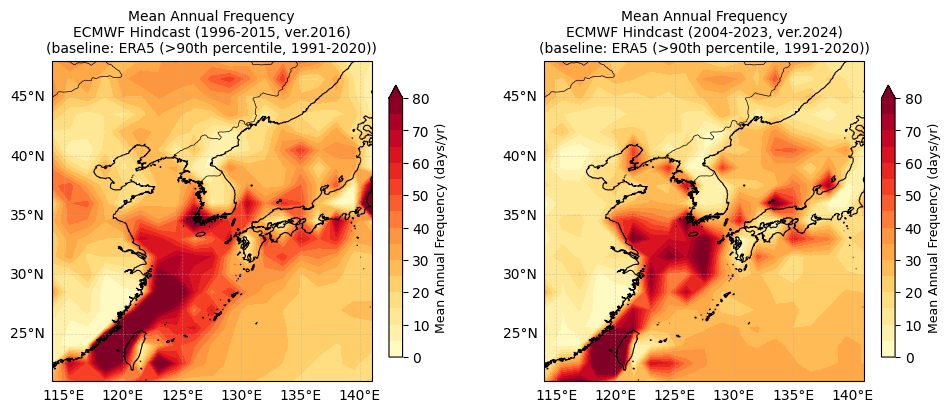

In [47]:
# Plot Mean Annual Frequency90: v16 vs v24
fig = plt.figure(figsize=(10, 4)) # 14, 6

# Target1:v2016
ax1 = plt.subplot(1,2,1, projection=ccrs.PlateCarree())
ax1.set_extent([114, 141, 21, 48], crs=ccrs.PlateCarree())

# Coast line
ax1.coastlines(resolution='10m', linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)

# latitude & longitude
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.5)
gl1.top_labels = False
gl1.right_labels = False

levels = np.arange(0, 81, 5)

cf1 = ax1.contourf(v16_mean_freq.longitude, v16_mean_freq.latitude, v16_mean_freq, levels=levels, cmap='YlOrRd', extend='max', transform=ccrs.PlateCarree())

# Colorbar1
cbar1 = plt.colorbar(cf1, ax=ax1, shrink=0.85, pad=0.04)
cbar1.set_label("Mean Annual Frequency (days/yr)", fontsize=9)

ax1.set_title("Mean Annual Frequency\nECMWF Hindcast (1996-2015, ver.2016)\n(baseline: ERA5 (>90th percentile, 1991-2020))", fontsize=10)

# Target2: v2024
ax2 = plt.subplot(1,2,2, projection=ccrs.PlateCarree())
ax2.set_extent([114, 141, 21, 48], crs=ccrs.PlateCarree())

# Coast line for v2024
ax2.coastlines(resolution='10m', linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)

# latitude & longitude
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.5)
gl2.top_labels = False
gl2.right_labels = False

cf2 = ax2.contourf(v24_mean_freq.longitude, v24_mean_freq.latitude, v24_mean_freq, levels=levels, cmap='YlOrRd', extend='max', transform=ccrs.PlateCarree())

# Colorbar2
cbar2 = plt.colorbar(cf2, ax=ax2, shrink=0.85, pad=0.04)
cbar2.set_label("Mean Annual Frequency (days/yr)", fontsize=9)

ax2.set_title("Mean Annual Frequency\nECMWF Hindcast (2004-2023, ver.2024)\n(baseline: ERA5 (>90th percentile, 1991-2020))", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(Output_Figures, "v16_v24_t2m_Mean_Annual_Frequency90.png"), dpi=300, bbox_inches="tight")
plt.show()

----------------------------------------------------------------------------



---



> Comparison of **the Week 3 time series of abnormal high temperatures (AHT) in 2023** from ECMWF S2S (ver. 2024) against the ERA5 climatology and threshold (1991–2020) at the target location (Seoul).

Setting **the coordinates of the Seoul** point to view the time series change of of the 2023 ECMWF abnormal high temperatures (AHT) relative to the ERA5 at the Seoul.

In [24]:
# Target point
target_lat = 37.57142
target_lon = 126.96582

*   Load ERA5 daily data

In [25]:
# Input ERA5 file
era5 = xr.open_dataset(os.path.join(Data_ERA5, "ERA5_7day_rolling_T2m_1940_2024.nc"))

- Load the other data

In [26]:
# Input ECMWF ver.2024
ds24 = xr.open_dataset(os.path.join(Data_ECMWF, "v2024_ECMWF_hindcast_T2M_w3_2004-2023.nc"))

# Input threshold: ERA5's threshold: 90 percentile of T2M (base: 1991-2020)
thr = xr.open_dataset(os.path.join(Data_ERA5, "T2m_thresholds_dataset.nc"))

In [27]:
print(era5)
print()
print(ds24)
print()
print(thr)

<xarray.Dataset> Size: 90MB
Dimensions:   (time: 31041, lat: 19, lon: 19)
Coordinates:
  * time      (time) datetime64[ns] 248kB 1940-01-01 1940-01-02 ... 2024-12-25
  * lat       (lat) float64 152B 48.0 46.5 45.0 43.5 ... 25.5 24.0 22.5 21.0
  * lon       (lon) float64 152B 114.0 115.5 117.0 118.5 ... 138.0 139.5 141.0
    doy       (time) int64 248kB ...
Data variables:
    t2m_7day  (time, lat, lon) float64 90MB ...

<xarray.Dataset> Size: 148MB
Dimensions:    (time: 7140, latitude: 72, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 57kB 2004-01-19 2004-01-20 ... 2024-01-15
  * latitude   (latitude) float64 576B 57.0 55.5 54.0 52.5 ... -46.5 -48.0 -49.5
  * longitude  (longitude) float64 576B 52.5 54.0 55.5 ... 156.0 157.5 159.0
Data variables:
    t2m        (time, latitude, longitude) float32 148MB ...

<xarray.Dataset> Size: 255MB
Dimensions:    (doy: 366, lat: 121, lon: 240)
Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 360 361 362 363 364 365

In [28]:
# Select nearest grid
ec = ds24.sel(latitude=target_lat, longitude=target_lon, method="nearest")
er = era5.sel(lat=target_lat, lon=target_lon, method="nearest")
thr = thr.sel(lat=target_lat, lon=target_lon, method="nearest")

In [33]:
print(ec['t2m'][:5].values)

[268.75552 269.8197  268.51157 266.18057 265.56418]


In [34]:
print(er['t2m_7day'][:5].values)

[-4.4110648  -5.44778181 -7.26111886 -8.24323556 -8.58987601]


In [35]:
print(thr['clim_90th'][:5].values)

[273.86090262 273.88648333 273.86090262 273.88648333 273.69202706]


- Need to convert Kelvin to Celsius

In [36]:
# Kelvin -> Celsius
ec_t2m = ec["t2m"] - 273.15
er_t2m = er
thr90 = thr["clim_90th"] - 273.15

- Necessary to check if there are duplicate dates in the ECMWF data

In [37]:
# Remove duplicated dates (ECMWF only)
time_index = pd.Index(ec_t2m.time.values)
duplicate = time_index.duplicated()
ec_t2m = ec_t2m.isel(time=~duplicate)
print("Duplicated dates removed:", duplicate.sum())

Duplicated dates removed: 80


- In order to compare the time series change of AHT in 2023 with **the Normal year**
- **Calculate Climatology**

In [38]:
# ECMWF climatology
# 2004-2023
print("Calculating ECMWF Climtology ...")
ec_clim = (ec_t2m.sel(time=slice("2004-01-01", "2023-12-31")).groupby("time.dayofyear").mean("time"))
ec_clim = ec_clim.rename({"dayofyear": "doy"})
#print(ec_clim)

Calculating ECMWF Climtology ...


> **Although the ECMWF hindcast uses** a climatology period of **2004–2023**, the ERA5 climatology could not be matched to this period **because the ERA5 threshold climatology is defined over the 1991–2020** reference period. Therefore, **the ERA5 climatology period used in this exercise is 1991–2020**.

In [39]:
# ERA5 climatology
# 1991-2020
print("Calculating ERA5 Climtology ...")
er_clim = (er_t2m.sel(time=slice("1991-01-01", "2020-12-31")).groupby("time.dayofyear").mean("time"))
er_clim = er_clim.rename({"dayofyear": "doy"})
#print(er_clim)

Calculating ERA5 Climtology ...


In [40]:
# set 2023 data
ec2023 = ec_t2m.sel(time=slice("2023-01-01", "2023-12-31"))
er2023 = er_t2m.sel(time=slice("2023-01-01", "2023-12-31"))

In [41]:
# Convert to DataFrame to plot
df_ec2023 = pd.DataFrame({"time": ec2023.time.values, "doy": ec2023.time.dt.dayofyear.values, "ecmwf": ec2023.values})
df_er2023 = pd.DataFrame({"time": er2023.time.values, "doy": er2023.time.dt.dayofyear.values, "era5": er2023['t2m_7day'].values})

df_ec_clim = pd.DataFrame({"doy": ec_clim.doy.values, "ecmwf_clim": ec_clim.values})
df_er_clim = pd.DataFrame({"doy": er_clim.doy.values, "era5_clim": er_clim['t2m_7day'].values})

df_thr = pd.DataFrame({"doy": thr90.doy.values, "thr90": thr90.values})

In [42]:
# Remove leap day
df_ec2023 = df_ec2023[df_ec2023.doy != 366]
df_er2023 = df_er2023[df_er2023.doy != 366]
df_ec_clim = df_ec_clim[df_ec_clim.doy != 366]
df_er_clim = df_er_clim[df_er_clim.doy != 366]
df_thr = df_thr[df_thr.doy != 366]

In [43]:
# Merge by DOY
df = (df_er2023
      .merge(df_ec2023[["doy", "ecmwf"]], on="doy", how="inner")
      .merge(df_er_clim, on="doy", how="inner")
      .merge(df_ec_clim, on="doy", how="inner")
      .merge(df_thr, on="doy", how="inner")
)

In [44]:
# sort by doy & check
df = df.sort_values("doy").reset_index(drop=True)
print(df.head())
print(df.tail())

        time  doy      era5     ecmwf  era5_clim  ecmwf_clim     thr90
0 2023-01-01    1 -2.133477 -6.252899  -2.900426   -4.626678  0.710903
1 2023-01-03    3 -0.977100 -9.224396  -3.135426   -4.622080  0.710903
2 2023-01-04    4 -0.263722 -8.989960  -3.198440   -4.609597  0.736483
3 2023-01-05    5  0.382353 -8.607117  -3.216798   -4.300277  0.542027
4 2023-01-06    6  1.224468 -8.076874  -3.268822   -4.337934  0.456725
          time  doy      era5     ecmwf  era5_clim  ecmwf_clim     thr90
348 2023-12-27  361  1.193964 -0.654114  -2.782521   -3.534845  0.931335
349 2023-12-28  362  1.163634 -0.855774  -2.705961   -2.867763  0.861696
350 2023-12-29  363  1.351395 -0.846954  -2.781416   -3.072064  0.709116
351 2023-12-30  364  1.675492  0.223511  -2.892633   -3.315155  0.549821
352 2023-12-31  365  1.652843 -0.269531  -2.945272   -4.000357  0.568365


In [45]:
# Shading masks
mask_era5 = df["era5"] > df["thr90"]
mask_ecmwf = df["ecmwf"] > df["thr90"]

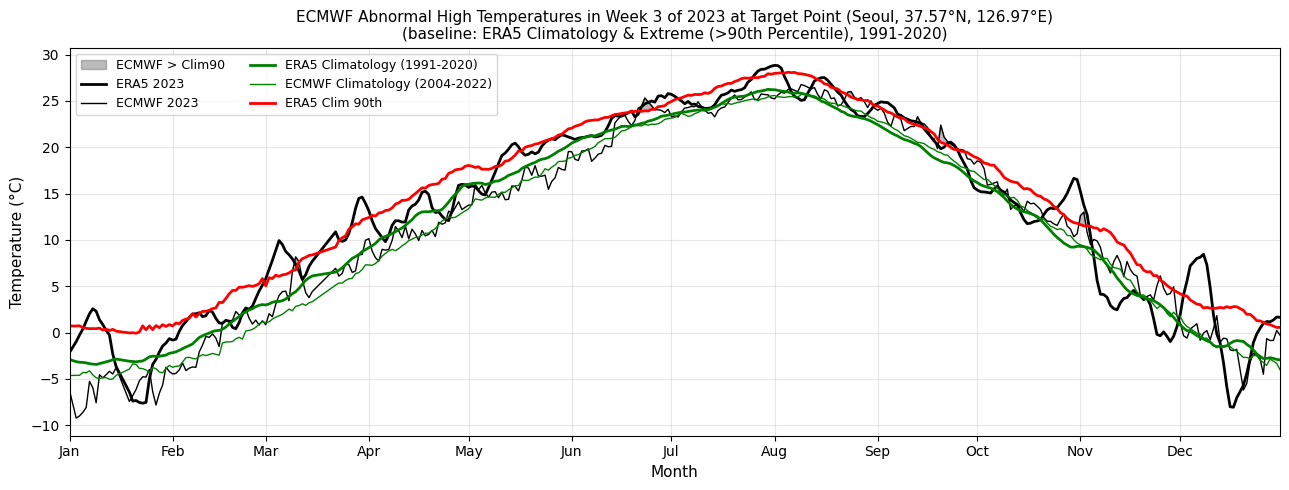

In [46]:
# Plot
plt.figure(figsize=(13, 5)) # 18, 7

# Shading:
#plt.fill_between(df["doy"], df["thr90"], df["era5"], where=mask_era5, interpolate=True, color="red", alpha=0.35, label="ERA5 > Clim90")
plt.fill_between(df["doy"], df["thr90"], df["ecmwf"], where=mask_ecmwf, interpolate=True, color="dimgray", alpha=0.45, label="ECMWF > Clim90")

# Lines
plt.plot(df["doy"], df["era5"], color="black", linewidth=2, linestyle="-", label="ERA5 2023")
plt.plot(df["doy"], df["ecmwf"], color="black", linewidth=1, linestyle="-", label="ECMWF 2023")
plt.plot(df["doy"], df["era5_clim"], color="green", linewidth=2, linestyle="-", label="ERA5 Climatology (1991-2020)")
plt.plot(df["doy"], df["ecmwf_clim"], color="green", linewidth=1, linestyle="-", label="ECMWF Climatology (2004-2022)")
plt.plot(df["doy"], df["thr90"], color="red", linewidth=2, linestyle="-",label="ERA5 Clim 90th")

# Axis
month_ticks = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan", "Feb", "Mar", "Apr","May", "Jun", "Jul", "Aug","Sep", "Oct", "Nov", "Dec"]

plt.xticks(month_ticks, month_labels)
plt.xlim(1, 365)
plt.ylabel("Temperature (°C)", fontsize=11)
plt.xlabel("Month", fontsize=11)
plt.title("ECMWF Abnormal High Temperatures in Week 3 of 2023 at Target Point (Seoul, 37.57°N, 126.97°E)\n" + "(baseline: ERA5 Climatology & Extreme (>90th Percentile), 1991-2020)", fontsize=11)

plt.grid(alpha=0.3)
plt.legend(loc="upper left", fontsize=9, ncol=2)
plt.tight_layout()

# Save
plt.savefig(os.path.join(Output_Figures, "v24_t2m_Extreme_y2023_Timeseries.png"), dpi=300, bbox_inches="tight")
plt.show()